In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/camelyon17_v1.0/metadata.csv")
df.head()

,Unnamed: 0,patient,node,x_coord,y_coord,tumor,slide,center,split
0,0,4,4,3328,21792,1,0,0,0
1,1,4,4,3200,22272,1,0,0,0
2,2,4,4,3168,22272,1,0,0,0
3,3,4,4,3328,21760,1,0,0,0
4,4,4,4,3232,22240,1,0,0,0


In [3]:
def get_filename(row):
    patient = "{:03}".format(row['patient'])
    node = row['node']
    x = row['x_coord']
    y = row['y_coord']
    return f"data/camelyon17_v1.0/patches/patient_{patient}_node_{node}/patch_patient_{patient}_node_{node}_x_{x}_y_{y}.png"

In [4]:
df["filename"] = df.apply(get_filename, axis=1)
df.head()

,Unnamed: 0,patient,node,x_coord,y_coord,tumor,slide,center,split,filename
0,0,4,4,3328,21792,1,0,0,0,data/camelyon17_v1.0/patches/patient_004_node_...
1,1,4,4,3200,22272,1,0,0,0,data/camelyon17_v1.0/patches/patient_004_node_...
2,2,4,4,3168,22272,1,0,0,0,data/camelyon17_v1.0/patches/patient_004_node_...
3,3,4,4,3328,21760,1,0,0,0,data/camelyon17_v1.0/patches/patient_004_node_...
4,4,4,4,3232,22240,1,0,0,0,data/camelyon17_v1.0/patches/patient_004_node_...


In [5]:
df.groupby("center")["tumor"].value_counts()

center  tumor
0       0        29718
        1        29718
1       0        17452
        1        17452
2       0        42527
        1        42527
3       0        64919
        1        64919
4       0        73361
        1        73361
Name: count, dtype: int64

In [6]:
from adapt import (
    set_seed, 
    resolve_dataset_class, 
    get_base_algorithm, 
    build_input_dir, 
    load_dataset, 
    load_run_record, 
    resolve_run_hparams, 
    build_adaptation_algorithm,
    run_adaptation_loop,
    get_default_adaptation_lr
)
import numpy as np
seed = 2026
set_seed(seed)

In [7]:
df_groups = df.groupby(["center", "tumor"])
filenames = []
groups = []
sample_size = 500
for idx in range(sample_size // 2):
    for group, group_df in df_groups:
        if not group[0] in [1, 4]:
            continue
        groups.append((int(group[0]), int(group[1])))
        filename = group_df.loc[np.random.choice(group_df.index), "filename"]
        filenames.append(filename)
print(groups)

[(1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0), (1, 1), (4, 0), (4, 1), (1, 0),

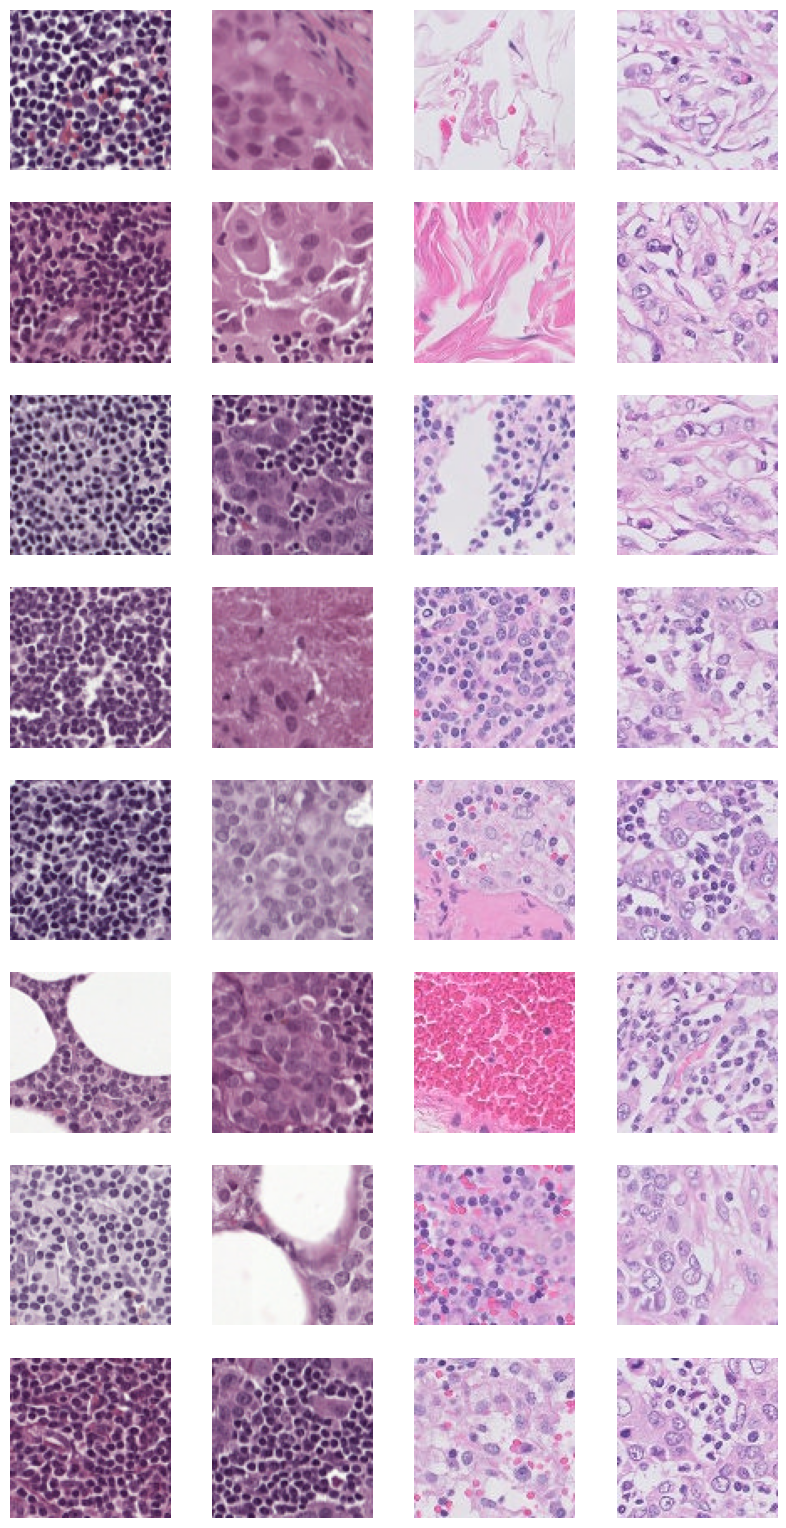

In [8]:
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
from PIL import Image
# plot images
plt.figure(figsize=(10, sample_size / 4 * 10))
for i, (filename, group) in enumerate(zip(filenames, groups)):
    if i >= 32:
        break
    plt.subplot(sample_size, 4, i + 1)
    img = plt.imread(filename, format="png")
    os.makedirs("figure1/images", exist_ok=True)
    plt.imsave(f"figure1/images/center_{group[0]}_tumor_{group[1]}_{i}.png", img)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [9]:
idx_source = 1
idx_target = 4
x_source, y_source, x_target, y_target = [], [], [], []
for i, (filename, group) in enumerate(zip(filenames, groups)):
    img = Image.open(filename).convert("RGB")
    y = torch.tensor(group[1])
    if group[0] == idx_source :
        x_source.append(img)
        y_source.append(y)
    if group[0] == idx_target :
        x_target.append(img)
        y_target.append(y)
        

y_source = torch.stack(y_source)
y_target = torch.stack(y_target)
print(len(x_target), y_target.shape)

500 torch.Size([500])


In [10]:
dataset_name = "WILDSCamelyon"
device = "cuda" if torch.cuda.is_available() else "cpu"
backbone = "resnet50-GN"
dataset_class = resolve_dataset_class(dataset_name)
envs = dataset_class.ENVIRONMENTS
all_env_indices = set(range(len(envs)))
envs, all_env_indices

(['Hospital 1', 'Hospital 2', 'Hospital 3', 'Hospital 4', 'Hospital 5'],
 {0, 1, 2, 3, 4})

In [11]:
train_env_set = set([idx_source])
available_test_envs = sorted(list(all_env_indices - train_env_set))

In [12]:
input_dir = build_input_dir(dataset_name, backbone, available_test_envs)
input_dir

'output/models/data_WILDSCamelyon_model_resnet50-GN_test_env_0_2_3_4_seed_0'

In [13]:
args, training_results = load_run_record(input_dir)
hparams = resolve_run_hparams(args)
dataset = load_dataset(args, hparams)

In [14]:
base_algorithm = get_base_algorithm(args, dataset, hparams, device, input_dir=input_dir)

In [15]:
from torch.utils.data import DataLoader
env_source = dataset[idx_source]
x_source_in = list(map(env_source.transform, x_source))
x_source_in = torch.stack(x_source_in)
env_target = dataset[idx_target]
x_target_in = list(map(env_target.transform, x_target))
x_target_in = torch.stack(x_target_in)

dataloader_source = DataLoader(x_source_in, batch_size=32, shuffle=False)
dataloader_target = DataLoader(x_target_in, batch_size=32, shuffle=False)

In [16]:
def get_embeddings_predictions(dataloader, model, device):
    embeddings = []
    predictions = []
    for b in dataloader:
        embeddings.append(model.featurizer(b.to(device)).cpu().detach())
        pred = model.classifier(model.featurizer(b.to(device))).cpu().detach().argmax(dim=1)
        predictions.append(pred)
    return torch.cat(embeddings), torch.cat(predictions)

In [17]:
embeddings_source, pred_source = get_embeddings_predictions(dataloader_source, base_algorithm, device)
embeddings_target_before, pred_target = get_embeddings_predictions(dataloader_target, base_algorithm, device)

In [18]:
algorithms = {
    "DSBR": {"ema_alpha": 0.0},
    "Tent": {},
}
algorithm_models = {}
batch_size = 32
for algorithm_name, adapt_hparams in algorithms.items():
    base_algorithm = get_base_algorithm(args, dataset, hparams, device, input_dir=input_dir)
    adapt_hparams["lr"] = get_default_adaptation_lr(backbone, batch_size, algorithm_name)
    adapt_algorithm = build_adaptation_algorithm(base_algorithm, algorithm_name, adapt_hparams, dataset, len(envs), device)
    adapt_dataloder = torch.utils.data.DataLoader(dataset[idx_target], batch_size=batch_size,
                                           shuffle=True,
                                                    num_workers=4, pin_memory=True)
    # results = run_adaptation_loop(adapt_algorithm.to(device), adapt_dataloder, None, device, log_interval=100)
    algorithm_models[algorithm_name] = adapt_algorithm.model

In [19]:
embeddings_target_after = {}
pred_target_after = {}
for n, algorithm in algorithms.items():
    model = algorithm_models[n]
    embeddings_target_after[n], pred_target_after[n] = \
        get_embeddings_predictions(dataloader_target, model, device)

In [20]:
all_embeddings = torch.cat([embeddings_source, embeddings_target_before] + list(embeddings_target_after.values()), dim=0)
all_predictions = torch.cat([pred_source, pred_target] + list(pred_target_after.values()), dim=0)
all_labels = torch.cat([y_source, y_target] + [y_target for _ in algorithms], dim=0)
print(all_embeddings.shape, all_predictions.shape, all_labels.shape)

torch.Size([2000, 2048]) torch.Size([2000]) torch.Size([2000])


In [21]:
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
tsne = TSNE(2, random_state=seed)
tsne_embeddings = tsne.fit_transform(all_embeddings.numpy())
tsne_embeddings.shape

(2000, 2)

In [22]:
class_names = dataset.classes
local_cluster_ditribution = torch.bincount(pred_target, minlength=len(class_names)) / len(pred_target)
print("Local cluster distribution:", local_cluster_ditribution)
print("DSBR weights:", 1 / (len(class_names) * local_cluster_ditribution))

Local cluster distribution: tensor([0.8320, 0.1680])
DSBR weights: tensor([0.6010, 2.9762])


In [23]:
x_min = tsne_embeddings[:, 0].min()
x_max = tsne_embeddings[:, 0].max()
y_min = tsne_embeddings[:, 1].min()
y_max = tsne_embeddings[:, 1].max()

x_pad = (x_max - x_min) * 0.05
y_pad = (y_max - y_min) * 0.05

unique_pred_classes, pred_counts = np.unique(all_predictions, return_counts=True)
samples_per_class = int(pred_counts.min())
rng = np.random.default_rng(seed)

balanced_indices = []
for cls in unique_pred_classes:
    cls_indices = np.where(all_predictions == cls)[0]
    chosen = rng.choice(cls_indices, size=samples_per_class, replace=False)
    balanced_indices.append(chosen)
balanced_indices = np.concatenate(balanced_indices)
rng.shuffle(balanced_indices)

x_knn = tsne_embeddings[balanced_indices]
y_knn = all_predictions[balanced_indices]

n_neighbors = min(50, len(x_knn))
clf = KNeighborsClassifier(n_neighbors=n_neighbors, weights="uniform")
clf.fit(x_knn, y_knn)

xx, yy = np.meshgrid(
    np.linspace(x_min - x_pad, x_max + x_pad, 300),
    np.linspace(y_min - y_pad, y_max + y_pad, 300)
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

In [24]:
default_cmap = plt.get_cmap("coolwarm")
background_alpha = 0.3
def plot_scatter(embeddings, labels, cmap=default_cmap):
    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=background_alpha, cmap=cmap)
    plt.contour(xx, yy, Z, colors='black', linewidths=2, linestyles='--', alpha=1)
    plt.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=labels,
        edgecolor="k",
        s=100,
        cmap=cmap
    )
    axis = plt.gca()
    axis.set_xticks([])
    axis.set_yticks([])

In [25]:
tsne_embeddings_source = tsne_embeddings[:len(x_source)]
tsne_embeddings_target_before = tsne_embeddings[len(x_source):len(x_source) + len(x_target)]
tsne_embeddings_target_after = {}
for i, algorithm_name in enumerate(algorithms.keys()):
    start_idx = len(x_source) + len(x_target) + i * len(x_target)
    end_idx = start_idx + len(x_target)
    tsne_embeddings_target_after[algorithm_name] = tsne_embeddings[start_idx:end_idx]

In [26]:
import os
os.makedirs("figure1", exist_ok=True)

In [ ]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 9,
    "font.weight": "normal",
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300
})
handles = []
labels = []
for j in range(len(class_names)):
    class_color = default_cmap(j / max(1, len(class_names)-1))
    handles.append(mlines.Line2D([], [], color=class_color, marker='o', linestyle='None', markersize=4, label=f"{class_names[j]} (True)"))
    labels.append(f"{class_names[j]} (True)")
    face_rgba = (class_color[0], class_color[1], class_color[2], background_alpha)
    handles.append(mpatches.Patch(facecolor=face_rgba, edgecolor='black', linestyle='--', linewidth=1.0, label=f"{class_names[j]} (Predicted)"))
    labels.append(f"{class_names[j]} (Predicted)")
    
boundary_line = mlines.Line2D([], [], color='black', linewidth=1, linestyle='--', alpha=1, label='Decision Boundary')
handles.append(boundary_line)
labels.append('Decision Boundary')
legend_fig = plt.figure(figsize=(max(2.5, 0.9 * len(handles)), 1.0))
legend_fig.legend(handles, labels, loc='center', ncol=min(len(handles), 5), frameon=False)
legend_fig.savefig("figure1/legend.pdf", dpi=300, bbox_inches='tight', pad_inches=0, transparent=True, facecolor='none', edgecolor='none')

<Figure size 450x100 with 0 Axes>

In [28]:
set_seed(seed)
plot_sample = np.random.choice(len(x_source), size=64, replace=False)

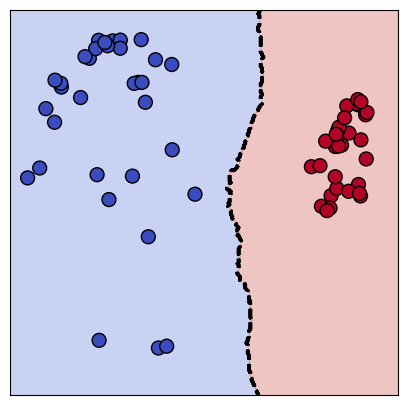

In [29]:
plot_scatter(tsne_embeddings_source[plot_sample], pred_source[plot_sample].cpu().numpy())
plt.savefig("figure1/source.pdf", dpi=300, bbox_inches='tight', pad_inches=0)

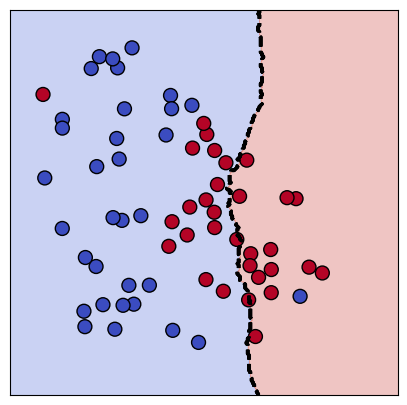

In [30]:
plot_scatter(tsne_embeddings_target_before[plot_sample], y_target[plot_sample].cpu().numpy())
plt.savefig("figure1/target_before.pdf", dpi=300, bbox_inches='tight', pad_inches=0)


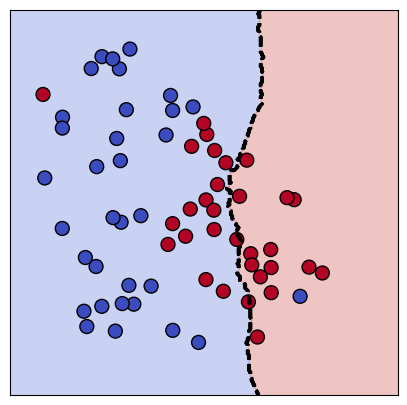

In [31]:
plot_scatter(tsne_embeddings_target_after["Tent"][plot_sample], y_target[plot_sample].cpu().numpy())
plt.savefig("figure1/target_after_Tent.pdf", dpi=300, bbox_inches='tight', pad_inches=0)

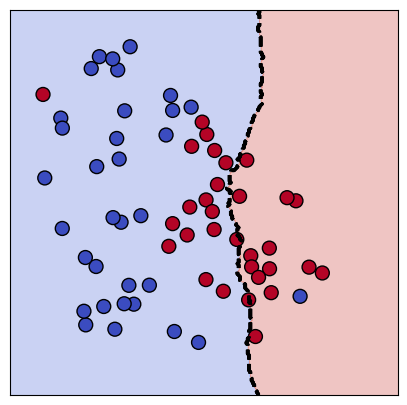

In [32]:
plot_scatter(tsne_embeddings_target_after["DSBR"][plot_sample], y_target[plot_sample].cpu().numpy())
plt.savefig("figure1/target_after_DSBR.pdf", dpi=300, bbox_inches='tight', pad_inches=0)